# $e^+ e^- \rightarrow \gamma, Z \rightarrow \mu^+ \mu^-$ with helicity amplitudes

## Introduction

In the notebook __EplusEminusToMuonPairs.ipynb__ we computed the differential cross section for $e^+ e^- \rightarrow \mu^+ \mu^-$ via photon exchange using **helicity amplitudes**. Here we add the second diagram of the electroweak theory at tree level, namely, $Z$ boson exchange, and compute the cross section *including the $\gamma$–$Z$ interference*. The helicity approach makes the interference almost trivial: for each of the 16 helicity configurations the amplitude is simply the *sum* of the photon and $Z$ amplitudes,
\begin{align}
    M_{\lambda} & = M_\lambda^\gamma + M_\lambda^Z ,
\end{align}
and $\langle |M|^2 \rangle = \frac{1}{4}\sum_\lambda |M_\lambda|^2$. The interference terms, which require a separate trace calculation in the traditional approach, emerge automatically when the modulus is squared.

### Feynman rules

We use the following vertex factors and propagators (unitary gauge) and keep the fermion masses throughout.

| | vertex / propagator |
| :--- | :--- |
| $\gamma f \bar{f}$ | $-i e Q_f \gamma^\mu$ |
| $Z f \bar{f}$ | $-i \dfrac{e}{2\sin\theta_W \cos\theta_W} \gamma^\mu (g_V^f - g_A^f \gamma^5)$ |
| photon | $\dfrac{-i g_{\mu\nu}}{q^2}$ |
| $Z$ | $\dfrac{-i (g_{\mu\nu} - q_\mu q_\nu / M_Z^2)}{q^2 - M_Z^2 + i M_Z \Gamma_Z}$ |

where $Q_f$ is the charge of the fermion in units of $e$ ($Q_e = Q_\mu = -1$), and
\begin{align}
    g_V^f & = T_3^f - 2 Q_f \sin^2\theta_W, \quad g_A^f = T_3^f, \quad T_3^e = T_3^\mu = -\tfrac{1}{2}.
\end{align}

### Matrix element

With $s = q^2 = (p_1 + p_2)^2$ and $e^2 = 4\pi\alpha$, the two diagrams give
\begin{align}
    M & = \frac{4 \pi \alpha}{s} \Big\{ Q_e Q_\mu \, g_{\mu\nu} V_e^\mu V_\mu^\nu
        + \chi(s) \Big[ g_{\mu\nu} Z_e^\mu Z_\mu^\nu - \frac{(q \cdot Z_e)(q \cdot Z_\mu)}{M_Z^2} \Big] \Big\},
\end{align}
where
\begin{align}
    V_e^\mu & = \overline{v}(p_2) \gamma^\mu u(p_1), &  A_e^\mu & = \overline{v}(p_2) \gamma^\mu \gamma^5 u(p_1), & Z_e^\mu & = g_V^e V_e^\mu - g_A^e A_e^\mu, \\
    V_\mu^\mu & = \overline{u}(p_3) \gamma^\mu v(p_4), & A_\mu^\mu & = \overline{u}(p_3) \gamma^\mu \gamma^5 v(p_4), & Z_\mu^\mu & = g_V^\mu V_\mu^\mu - g_A^\mu A_\mu^\mu,
\end{align}
are the vector, axial vector, and $Z$ currents, and
\begin{align}
    \chi(s) & = \frac{1}{4\sin^2\theta_W\cos^2\theta_W} \, \frac{s}{s - M_Z^2 + i M_Z \Gamma_Z} \equiv \chi_r + i \chi_i
\end{align}
is the (complex) ratio of the $Z$ to photon propagators, including the couplings. Note that the photon and $Z$ diagrams enter with the *same* sign: each is the product of two vertex factors and one propagator, i.e., three factors of $-i$.

__Tips__: 
  * Use __esc r__ to disable a cell
  * Use __esc y__ to reactivate it
  * Use __esc m__ to go to markdown mode
  * Shift + return to execute a cell

In [1]:
# load symbolic algebra module
import sympy as sm
from sympy.matrices import Matrix

# gamma matrices
from sympy.physics.matrices import mgamma

# complex number 0 + I
from sympy import I

# numerical and plotting modules
import numpy as np
import matplotlib.pyplot as plt

# enable pretty printing of symbolic equations
from IPython.display import display, Math
sm.init_printing()

## Define standard matrices

$\gamma^0, \gamma^1, \gamma^2, \gamma^3$ in the Dirac representation, $\gamma^5 = i \gamma^0 \gamma^1 \gamma^2 \gamma^3$, and the Minkowski metric $g_{\mu\nu} = \text{diag}(1, -1, -1, -1)$. 

We verify the Clifford algebra $\gamma^\mu \gamma^\nu + \gamma^\nu \gamma^\mu = 2 g^{\mu\nu}$, that $\gamma^5$ anti-commutes with every $\gamma^\mu$, and that `mgamma(5)` is indeed $i \gamma^0 \gamma^1 \gamma^2 \gamma^3$. This matters here because, unlike the photon, the $Z$ couples to the axial vector current, so the sign convention of $\gamma^5$ fixes which helicities couple via $g_V + g_A$ and which via $g_V - g_A$.

In [2]:
# Gamma matrices (upper index)
G   = [mgamma(mu) for mu in range(4)]
G0  = G[0]
G5  = mgamma(5)

# 4x4 unit matrix
ONE = sm.eye(4)

# Minkowski metric (+,-,-,-)
g   = sm.diag(1, -1, -1, -1)

def dot(a, b):
    # Lorentz-invariant product a.b = g_{mu nu} a^mu b^nu of two contravariant 4-vectors
    return (a.transpose() * g * b)[0]

clifford = all(G[mu]*G[nu] + G[nu]*G[mu] == 2*g[mu, nu]*ONE 
               for mu in range(4) for nu in range(4))
anti     = all(G5*G[mu] + G[mu]*G5 == sm.zeros(4) for mu in range(4))
print('Clifford algebra satisfied:     ', clifford)
print('gamma5 anti-commutes with G^mu: ', anti)
print('gamma5 = i G^0 G^1 G^2 G^3:     ', G5 == I*G[0]*G[1]*G[2]*G[3])
G5

Clifford algebra satisfied:      True
gamma5 anti-commutes with G^mu:  True
gamma5 = i G^0 G^1 G^2 G^3:      True


⎡0  0  1  0⎤
⎢          ⎥
⎢0  0  0  1⎥
⎢          ⎥
⎢1  0  0  0⎥
⎢          ⎥
⎣0  1  0  0⎦

## Helicity spinors

In __EplusEminusToMuonPairs.ipynb__ we derived the 2-component helicity spinors in spherical polar coordinates, that is, the eigen-spinors of $\sigma\cdot\mathbf{\hat{p}}$ with eigenvalues $\pm 1$,
\begin{align}
    \phi_\uparrow & = \begin{pmatrix} \cos\frac{\theta}{2} \\ e^{i\phi} \sin\frac{\theta}{2} \end{pmatrix}, \quad
    \phi_\downarrow = \begin{pmatrix} \sin\frac{\theta}{2} \\ -e^{i\phi} \cos\frac{\theta}{2} \end{pmatrix},
\end{align}
and the Dirac helicity spinors (normalized to $2E$)
\begin{align}
& \textbf{particles} \nonumber\\
u_{\uparrow} & = \sqrt{E+m} \begin{pmatrix} \phi_\uparrow \\ a \, \phi_\uparrow \end{pmatrix},\quad
u_{\downarrow} = \sqrt{E+m} \begin{pmatrix} \phi_\downarrow \\ -a \, \phi_\downarrow \end{pmatrix}, \\
& \textbf{antiparticles} \nonumber\\
v_{\downarrow} & = \sqrt{E+m} \begin{pmatrix} a \, \phi_\uparrow \\ \phi_\uparrow \end{pmatrix},\quad
v_{\uparrow} = \sqrt{E+m} \begin{pmatrix} -a \, \phi_\downarrow \\ \phi_\downarrow \end{pmatrix},
\end{align}
with
\begin{align}
    \sqrt{E + m} & = \sqrt{E} \sqrt{1 + \sqrt{1 - \beta^2}}, \quad a = \frac{p}{E + m} = \frac{\beta} {1 + \sqrt{1 - \beta^2}}.
\end{align}
We use exactly the same spinors, and therefore the same phase conventions, as in the photon-only notebook. Phase conventions cancel in $|M_\lambda|^2$ provided the same spinors are used in *both* diagrams, which is the case here.

In [3]:
theta, fi = sm.symbols(r'\theta, \phi', real=True)
beta      = sm.symbols(r'\beta', positive=True)
E, s, MZ  = sm.symbols('E, s, M_Z', positive=True)

# 2-component helicity spinors
phi_up = Matrix([sm.cos(theta/2),  sm.exp(I*fi)*sm.sin(theta/2)])
phi_dn = Matrix([sm.sin(theta/2), -sm.exp(I*fi)*sm.cos(theta/2)])

# verify that they are eigen-spinors of sigma.p_hat
sigma_phat = Matrix([[sm.cos(theta), sm.sin(theta)*sm.exp(-I*fi)], 
                     [sm.sin(theta)*sm.exp(I*fi), -sm.cos(theta)]])
print('sigma.p_hat phi_up - phi_up = ', list(sm.simplify(sigma_phat*phi_up - phi_up)))
print('sigma.p_hat phi_dn + phi_dn = ', list(sm.simplify(sigma_phat*phi_dn + phi_dn)))
phi_up, phi_dn

sigma.p_hat phi_up - phi_up =  [0, 0]


sigma.p_hat phi_dn + phi_dn =  [0, 0]


⎛⎡       ⎛\theta⎞    ⎤  ⎡       ⎛\theta⎞     ⎤⎞
⎜⎢    cos⎜──────⎟    ⎥  ⎢    sin⎜──────⎟     ⎥⎟
⎜⎢       ⎝  2   ⎠    ⎥  ⎢       ⎝  2   ⎠     ⎥⎟
⎜⎢                   ⎥, ⎢                    ⎥⎟
⎜⎢ ⅈ⋅\phi    ⎛\theta⎞⎥  ⎢  ⅈ⋅\phi    ⎛\theta⎞⎥⎟
⎜⎢ℯ      ⋅sin⎜──────⎟⎥  ⎢-ℯ      ⋅cos⎜──────⎟⎥⎟
⎝⎣           ⎝  2   ⎠⎦  ⎣            ⎝  2   ⎠⎦⎠

In [4]:
a = beta/(1 + sm.sqrt(1 - beta**2))
N = sm.sqrt(E)*sm.sqrt(1 + sm.sqrt(1 - beta**2))

# Dirac helicity spinors for particles
u_up = N*Matrix.vstack(phi_up,  a*phi_up)
u_dn = N*Matrix.vstack(phi_dn, -a*phi_dn)

# Dirac helicity spinors for antiparticles
v_dn = N*Matrix.vstack( a*phi_up, phi_up)
v_up = N*Matrix.vstack(-a*phi_dn, phi_dn)

u_up, u_dn, v_up, v_dn

⎛⎡           _____________________                ⎤  ⎡           _____________ ↪
⎜⎢          ╱    ____________                     ⎥  ⎢          ╱    _________ ↪
⎜⎢         ╱    ╱          2          ⎛\theta⎞    ⎥  ⎢         ╱    ╱          ↪
⎜⎢    √E⋅╲╱   ╲╱  1 - \beta   + 1 ⋅cos⎜──────⎟    ⎥  ⎢    √E⋅╲╱   ╲╱  1 - \bet ↪
⎜⎢                                    ⎝  2   ⎠    ⎥  ⎢                         ↪
⎜⎢                                                ⎥  ⎢                         ↪
⎜⎢       _____________________                    ⎥  ⎢        ________________ ↪
⎜⎢      ╱    ____________                         ⎥  ⎢       ╱    ____________ ↪
⎜⎢     ╱    ╱          2        ⅈ⋅\phi    ⎛\theta⎞⎥  ⎢      ╱    ╱          2  ↪
⎜⎢√E⋅╲╱   ╲╱  1 - \beta   + 1 ⋅ℯ      ⋅sin⎜──────⎟⎥  ⎢-√E⋅╲╱   ╲╱  1 - \beta   ↪
⎜⎢                                        ⎝  2   ⎠⎥  ⎢                         ↪
⎜⎢                                                ⎥  ⎢                         ↪
⎜⎢                         ⎛

## Kinematics

As before, in the center of mass frame, with $E = \sqrt{s}/2$,
\begin{align}
    p_1 & = E(1, 0, 0, \beta_1), \tag{$e^-$}\\
    p_2 & = E(1, 0, 0,-\beta_1), \tag{$e^+$}\\
    p_3 & = E(1, \beta_3 \sin\theta, 0, \beta_3 \cos\theta), \tag{$\mu^-$}\\
    p_4 & = E(1,-\beta_3 \sin\theta, 0,-\beta_3 \cos\theta), \tag{$\mu^+$}
\end{align}
and, without loss of generality, $\phi = 0$. The $e^+$ moves in the direction $\theta = -\pi$ and the $\mu^+$ in the direction $\theta + \pi$.

In [5]:
beta1, beta3 = sm.symbols(r'\beta_1, \beta_3', positive=True)

def subs_spinor(u, Beta, Theta):
    return u.subs({beta: Beta, fi: 0}).subs({theta: Theta})

# e- (1) and e+ (2)
u1 = [subs_spinor(u_up, beta1, 0),      subs_spinor(u_dn, beta1, 0)]
v2 = [subs_spinor(v_up, beta1, -sm.pi), subs_spinor(v_dn, beta1, -sm.pi)]

# mu- (3) and mu+ (4)
u3 = [subs_spinor(u_up, beta3, theta),         subs_spinor(u_dn, beta3, theta)]
v4 = [subs_spinor(v_up, beta3, theta + sm.pi), subs_spinor(v_dn, beta3, theta + sm.pi)]

u1, v2

⎛⎡⎡       ______________________⎤  ⎡              0               ⎤⎤  ⎡⎡       ↪
⎜⎢⎢      ╱    _____________     ⎥  ⎢                              ⎥⎥  ⎢⎢  ──── ↪
⎜⎢⎢     ╱    ╱           2      ⎥  ⎢        ______________________⎥⎥  ⎢⎢       ↪
⎜⎢⎢√E⋅╲╱   ╲╱  1 - \beta₁   + 1 ⎥  ⎢       ╱    _____________     ⎥⎥  ⎢⎢     ╱ ↪
⎜⎢⎢                             ⎥  ⎢      ╱    ╱           2      ⎥⎥  ⎢⎢    ╱  ↪
⎜⎢⎢              0              ⎥  ⎢-√E⋅╲╱   ╲╱  1 - \beta₁   + 1 ⎥⎥  ⎢⎢  ╲╱   ↪
⎜⎢⎢                             ⎥  ⎢                              ⎥⎥  ⎢⎢       ↪
⎜⎢⎢         √E⋅\beta₁           ⎥, ⎢              0               ⎥⎥, ⎢⎢       ↪
⎜⎢⎢ ──────────────────────────  ⎥  ⎢                              ⎥⎥  ⎢⎢       ↪
⎜⎢⎢     ______________________  ⎥  ⎢          √E⋅\beta₁           ⎥⎥  ⎢⎢       ↪
⎜⎢⎢    ╱    _____________       ⎥  ⎢  ──────────────────────────  ⎥⎥  ⎢⎢       ↪
⎜⎢⎢   ╱    ╱           2        ⎥  ⎢      ______________________  ⎥⎥  ⎢⎢       ↪
⎜⎢⎢ ╲╱   ╲╱  1 - \beta₁   + 

## Vector and axial vector currents

Compute $\overline{w}_1 \gamma^\mu \Gamma w_2$ with $\Gamma = 1$ (vector) or $\Gamma = \gamma^5$ (axial vector). As in the first notebook, the function returns the *contravariant* components $\mu = 0, 1, 2, 3$, and the complex conjugate is taken by hand, $i \rightarrow -i$, since all other symbols are real. The helper `simplify_beta` makes sympy simplify expressions involving $\sqrt{1 - \beta^2}$; this keeps the final result compact.

In [6]:
r = sm.symbols('r', positive=True)

def simplify_beta(expr):
    # sympy does not easily see that, e.g., (beta^2 - sqrt(1-beta^2) - 1)/(sqrt(1-beta^2) + 1) = -sqrt(1-beta^2).
    # Help it: write sqrt(1 - beta^2) = r and beta = sqrt(1 - r^2), simplify, then transform back.
    for b in (beta1, beta3):
        expr = expr.subs(sm.sqrt(1 - b**2), r).subs(b, sm.sqrt(1 - r**2))
        expr = sm.factor(sm.simplify(expr))
        expr = expr.subs(sm.sqrt(1 - r)*sm.sqrt(1 + r), sm.sqrt(1 - r**2))
        expr = expr.subs(r, sm.sqrt(1 - b**2))
    return sm.simplify(expr)

def current(w1, w2, Gamma=ONE):
    # Dirac conjugate
    w1bar = w1.transpose().subs({I: -I}) * G0
    return Matrix([simplify_beta(sm.trigsimp((w1bar*G[mu]*Gamma*w2)[0].expand())) 
                   for mu in range(4)])

label = ['up', 'dn']

# electron currents: vbar(2) gamma^mu [gamma^5] u(1)
Ve, Ae, Jelabel = [], [], []
for i, v in enumerate(v2):
    for j, u in enumerate(u1):
        Jelabel.append('%s(2) %s(1)' % (label[i], label[j]))
        Ve.append(current(v, u))
        Ae.append(current(v, u, G5))

# muon currents: ubar(3) gamma^mu [gamma^5] v(4)
Vm, Am, Jmlabel = [], [], []
for i, u in enumerate(u3):
    for j, v in enumerate(v4):
        Jmlabel.append('%s(3) %s(4)' % (label[i], label[j]))
        Vm.append(current(u, v))
        Am.append(current(u, v, G5))

for lab, V, A in zip(Jelabel + Jmlabel, Ve + Vm, Ae + Am):
    print(lab)
    display(Math(r'V^\mu = %s, \quad A^\mu = %s' % (sm.latex(V.T), sm.latex(A.T))))
    print('-'*60)

up(2) up(1)


<IPython.core.display.Math object>

------------------------------------------------------------
up(2) dn(1)


<IPython.core.display.Math object>

------------------------------------------------------------
dn(2) up(1)


<IPython.core.display.Math object>

------------------------------------------------------------
dn(2) dn(1)


<IPython.core.display.Math object>

------------------------------------------------------------
up(3) up(4)


<IPython.core.display.Math object>

------------------------------------------------------------
up(3) dn(4)


<IPython.core.display.Math object>

------------------------------------------------------------
dn(3) up(4)


<IPython.core.display.Math object>

------------------------------------------------------------
dn(3) dn(4)


<IPython.core.display.Math object>

------------------------------------------------------------


Notice that the *vector* currents have $V^0 = 0$ for every helicity combination, whereas the *axial* currents have $A^0 \neq 0$ for the helicity combinations $\uparrow\uparrow$ and $\downarrow\downarrow$ (for the electron: $e^+$ and $e^-$ with the same helicity label). These are precisely the combinations whose amplitudes vanish in the massless limit, and one can check that $A^0 \propto \sqrt{1 - \beta^2} = m/E$.

Since $q = p_1 + p_2 = (2E, 0, 0, 0)$, $q_\mu J^\mu = 2E J^0$. So the vector currents are conserved, $q \cdot V = 0$, but the axial vector currents of massive fermions are **not**, $q \cdot A \propto m$. This is why the $q_\mu q_\nu/M_Z^2$ term of the $Z$ propagator must be kept (and why the contraction must use the metric).

q.V (electron): [0, 0, 0, 0]
q.V (muon):     [0, 0, 0, 0]

q.A (electron):


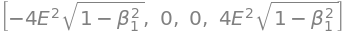

q.A (muon):


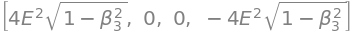

In [7]:
print('q.V (electron):', [sm.simplify(2*E*V[0]) for V in Ve])
print('q.V (muon):    ', [sm.simplify(2*E*V[0]) for V in Vm])
print()
print('q.A (electron):')
display([sm.simplify(2*E*A[0]) for A in Ae])
print('q.A (muon):')
display([sm.simplify(2*E*A[0]) for A in Am])

## The 16 helicity amplitudes

We treat the couplings, charges and $\chi = \chi_r + i \chi_i$ as real symbols so that the final result can be checked against the textbook formula before any numbers are inserted.

In [8]:
alpha = sm.symbols(r'\alpha', positive=True)
gVe, gAe, gVm, gAm = sm.symbols(r'g_V^e, g_A^e, g_V^\mu, g_A^\mu', real=True)
Qe, Qm             = sm.symbols(r'Q_e, Q_\mu', real=True)
chi_r, chi_i       = sm.symbols(r'\chi_r, \chi_i', real=True)
chi = chi_r + I*chi_i

# 4-momentum transfer in the CM frame
q = Matrix([2*E, 0, 0, 0])

M = []   # amplitudes
L = []   # labels
for i in range(4):
    Ze = gVe*Ve[i] - gAe*Ae[i]
    for j in range(4):
        Zm = gVm*Vm[j] - gAm*Am[j]
        
        Mgamma = Qe*Qm*dot(Ve[i], Vm[j])
        MZ_    = chi*(dot(Ze, Zm) - dot(q, Ze)*dot(q, Zm)/MZ**2)
        
        M.append( sm.expand(4*sm.pi*alpha/s * (Mgamma + MZ_)) )
        L.append( Jelabel[i] + ' * ' + Jmlabel[j] )
len(M)

## Sum over helicities and the differential cross section

\begin{align}
    \langle |M|^2 \rangle & = \frac{1}{4} \sum_{\lambda=1}^{16} M^*_\lambda M_\lambda, \\
    \frac{d\sigma}{d\Omega} & = \frac{1}{64\pi^2 s}\frac{\beta_3}{\beta_1} \langle |M|^2 \rangle .
\end{align}

The result has the structure
\begin{align}
    \langle |M|^2 \rangle & = 16\pi^2\alpha^2 \left[ Q_e^2 Q_\mu^2 X_{\gamma\gamma} + 2 Q_e Q_\mu \chi_r X_{\gamma Z} + |\chi|^2 X_{ZZ} \right],
\end{align}
that is, photon, interference, and $Z$ terms. Note that only the *real* part of $\chi$ enters the interference term, and $\chi_r$ changes sign at $\sqrt{s} = M_Z$.

In [9]:
MM = sum([sm.expand(x.subs({I: -I})*x) for x in M]) / 4
MM = sm.expand(MM.subs({E: sm.sqrt(s)/2}))

K = 16*sm.pi**2*alpha**2
def tidy(expr):
    # write sin^2 = 1 - cos^2 and collect powers of cos(theta)
    expr = sm.expand(sm.expand(expr).subs({sm.sin(theta)**2: 1 - sm.cos(theta)**2}))
    return sm.collect(expr, sm.cos(theta), sm.factor)

X_gg = tidy(MM.subs({chi_r: 0, chi_i: 0}) / (K*Qe**2*Qm**2))
X_gZ = tidy(sm.diff(MM, chi_r).subs({chi_r: 0, chi_i: 0}) / (2*K*Qe*Qm))
X_ZZ = tidy(sm.diff(MM, chi_i, 2) / (2*K))

# check the decomposition
print('decomposition exact:', 
      sm.simplify(MM - K*(Qe**2*Qm**2*X_gg + 2*Qe*Qm*chi_r*X_gZ + (chi_r**2 + chi_i**2)*X_ZZ)) == 0)
X_gg, X_gZ

decomposition exact: True


$X_{ZZ}$ contains, in addition, a tiny term proportional to $1/M_Z^2$ from the $q_\mu q_\nu$ part of the $Z$ propagator (see check 3 below). Without that term,

In [10]:
X_ZZ_0 = tidy(sm.expand(X_ZZ).subs({1/MZ**2: 0, 1/MZ**4: 0}))
X_ZZ_0

In [11]:
diff_xsec = (beta3/beta1) * MM / (64*sm.pi**2*s)

## Checks

### 1. Photon exchange only
Setting $\chi = 0$ must reproduce the result of __EplusEminusToMuonPairs.ipynb__,
$$\langle |M|^2 \rangle = 16\pi^2\alpha^2 Q_e^2 Q_\mu^2 (3 - \beta_1^2 - \beta_3^2 + \beta_1^2\beta_3^2\cos^2\theta).$$

In [12]:
sm.simplify(X_gg - (3 - beta1**2 - beta3**2 + beta1**2*beta3**2*sm.cos(theta)**2))

### 2. Massless limit
For $\beta_1 = \beta_3 = 1$ the textbook result (see, e.g., Halzen & Martin, *Quarks and Leptons*, §13.6) is
\begin{align}
    \frac{d\sigma}{d\Omega} = \frac{\alpha^2}{4s} \Big\{ & (1 + \cos^2\theta)\left[Q_e^2Q_\mu^2 + 2 Q_e Q_\mu g_V^e g_V^\mu \chi_r + |\chi|^2 (g_V^{e2} + g_A^{e2})(g_V^{\mu2} + g_A^{\mu2})\right] \nonumber\\
    + \, & 2\cos\theta \left[ 2 Q_e Q_\mu g_A^e g_A^\mu \chi_r + 4 |\chi|^2 g_V^e g_A^e g_V^\mu g_A^\mu \right] \Big\}.
\end{align}
The term linear in $\cos\theta$ produces the forward-backward asymmetry.

In [13]:
c = sm.cos(theta)
book = alpha**2/(4*s) * (
    (1 + c**2)*(Qe**2*Qm**2 + 2*Qe*Qm*gVe*gVm*chi_r 
                + (chi_r**2 + chi_i**2)*(gVe**2 + gAe**2)*(gVm**2 + gAm**2))
    + 2*c*(2*Qe*Qm*gAe*gAm*chi_r + 4*(chi_r**2 + chi_i**2)*gVe*gAe*gVm*gAm) )

diff_xsec_0 = sm.simplify(diff_xsec.subs({beta1: 1, beta3: 1}))
print('difference from textbook:', sm.simplify(diff_xsec_0 - book))

difference from textbook: 0


### 3. The $q_\mu q_\nu / M_Z^2$ term
The part of $\langle |M|^2\rangle$ that depends on $M_Z$ explicitly comes only from the $q_\mu q_\nu$ term of the $Z$ propagator. It factorizes into
$$|\chi|^2 g_A^{e2} g_A^{\mu2} (1 - \beta_1^2)(1-\beta_3^2)\left(\frac{s}{M_Z^2}\right)\left(\frac{s}{M_Z^2} - 2\right) = |\chi|^2 g_A^{e2} g_A^{\mu2} \frac{16 m_e^2 m_\mu^2}{s^2}\left(\frac{s}{M_Z^2}\right)\left(\frac{s}{M_Z^2} - 2\right),$$
since $(1 - \beta^2) s = 4 m^2$. It is proportional to $m_e^2 m_\mu^2$ and is utterly negligible for $e^+e^-\rightarrow\mu^+\mu^-$, but it is there and the helicity calculation captures it exactly.

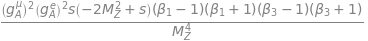

In [14]:
X_ZZ_MZ = sm.factor(sm.expand(X_ZZ) - sm.expand(X_ZZ).subs({1/MZ**2: 0, 1/MZ**4: 0}))
X_ZZ_MZ

### 4. Heavy fermion near threshold, $Z$ exchange only
With $\beta_1 = 1$, $\beta_3 = \beta$ and only $Z$ exchange (and ignoring the $q_\mu q_\nu$ term, which vanishes for $m_e = 0$), the total cross section should be proportional to the well-known combination
$$ \beta \, \frac{3 - \beta^2}{2} \, g_V^{\mu2} + \beta^3 g_A^{\mu2},$$
that is, the vector coupling turns on as $\beta$ while the axial coupling turns on as $\beta^3$ (a $P$-wave).

In [15]:
b = sm.symbols('beta', positive=True)
dxs_Z = diff_xsec.subs({beta1: 1, beta3: b, Qe: 0})
sigma_Z = sm.simplify(sm.integrate(2*sm.pi*dxs_Z*sm.sin(theta), (theta, 0, sm.pi)))
ratio   = sm.factor(sigma_Z / (b*(3 - b**2)/2*gVm**2 + b**3*gAm**2))
print('ratio is independent of beta and of the muon couplings:', 
      not ratio.has(b) and not ratio.has(gVm) and not ratio.has(gAm))
ratio

ratio is independent of beta and of the muon couplings: True


## Helicity amplitudes in the massless limit

In the massless limit only 4 of the 16 amplitudes survive. Define the chiral couplings
\begin{align}
    g_L = g_V + g_A, \quad g_R = g_V - g_A .
\end{align}
Since $\gamma^5 u_L = - u_L$, the $Z$ current of a left-handed fermion is $g_V V - g_A A = (g_V + g_A) V = g_L V$, and similarly $g_R$ for a right-handed fermion. Each amplitude should therefore be of the form
\begin{align}
    M_{ij} & = \pm 4\pi\alpha (1 \pm \cos\theta) \left[ Q_e Q_\mu + \chi \, g^e_i g^\mu_j \right], \quad i, j \in \{L, R\},
\end{align}
with $(1 + \cos\theta)$ when the initial and final fermions have the *same* chirality and $(1 - \cos\theta)$ otherwise. These are the angular-momentum conserving amplitudes: in the massless limit the $e^+e^-$ pair has $J_z = \pm 1$ along the beam.

The labels below map onto chirality as follows: $e^-_L e^+_R$ = `up(2) dn(1)`, $e^-_R e^+_L$ = `dn(2) up(1)`, $\mu^-_L \mu^+_R$ = `dn(3) up(4)`, $\mu^-_R \mu^+_L$ = `up(3) dn(4)`.

In [16]:
gLe, gRe, gLm, gRm = sm.symbols(r'g_L^e, g_R^e, g_L^\mu, g_R^\mu', real=True)
to_chiral = {gVe: (gLe + gRe)/2, gAe: (gLe - gRe)/2, 
             gVm: (gLm + gRm)/2, gAm: (gLm - gRm)/2}

chir_e = {'up(2) dn(1)': 'L', 'dn(2) up(1)': 'R'}
chir_m = {'dn(3) up(4)': 'L', 'up(3) dn(4)': 'R'}

print('Matrix elements in the massless limit\n')
M0, L0 = [], []
for label_, m in zip(L, M):
    y = m.subs({beta1: 1, beta3: 1})
    if y == 0: continue
    y = sm.factor(sm.expand(y.subs(to_chiral).subs({E: sm.sqrt(s)/2})))
    le, lm = label_.split(' * ')
    print('%-26s  e: %s  mu: %s' % (label_, chir_e[le], chir_m[lm]))
    display(y)
    print('-'*60)
    M0.append(y)
    L0.append((chir_e[le], chir_m[lm]))

Matrix elements in the massless limit



up(2) dn(1) * up(3) dn(4)   e: L  mu: R


------------------------------------------------------------


up(2) dn(1) * dn(3) up(4)   e: L  mu: L


------------------------------------------------------------


dn(2) up(1) * up(3) dn(4)   e: R  mu: R


------------------------------------------------------------


dn(2) up(1) * dn(3) up(4)   e: R  mu: L


------------------------------------------------------------


## Numerical results

We now insert numbers. For simplicity, we use a fixed value of $\alpha$, namely, $\alpha(M_Z) \approx 1/128.9$, and the effective leptonic weak mixing angle; we ignore radiative corrections such as initial state radiation, which, in reality, distort the $Z$ line shape considerably. We keep the muon mass, but set $m_e = 0$ ($\beta_1 = 1$).

| parameter | value |
| :--- | :--- |
| $M_Z$ | 91.1876 GeV |
| $\Gamma_Z$ | 2.4955 GeV |
| $\sin^2\theta_W$ | 0.2315 |
| $\alpha$ | 1/128.9 |
| $m_\mu$ | 0.10566 GeV |
| $\hbar^2 c^2$ | 0.3894 mb GeV$^2$ = $0.3894\times 10^6$ nb GeV$^2$ |

In [17]:
MZ_  = 91.1876     # GeV
GZ_  = 2.4955      # GeV
sw2_ = 0.2315
alf_ = 1/128.9
mmu_ = 0.10566     # GeV
GEV2NB = 0.3894e6  # nb GeV^2

T3   = -0.5
Q_   = -1.0
gV_  = T3 - 2*Q_*sw2_
gA_  = T3
print('g_V = %8.5f, g_A = %8.5f' % (gV_, gA_))
print('g_L = %8.5f, g_R = %8.5f' % (gV_ + gA_, gV_ - gA_))

def chi_(s_):
    return s_/(s_ - MZ_**2 + 1j*MZ_*GZ_) / (4*sw2_*(1 - sw2_))

g_V = -0.03700, g_A = -0.50000
g_L = -0.53700, g_R =  0.46300


Next, integrate $d\sigma/d\Omega$ over the forward ($\cos\theta > 0$) and backward ($\cos\theta < 0$) hemispheres symbolically, then convert the results to numerical functions of $s$. The forward-backward asymmetry is
\begin{align}
    A_{FB} & = \frac{\sigma_F - \sigma_B}{\sigma_F + \sigma_B}.
\end{align}

In [18]:
x = sm.symbols('x', real=True)   # x = cos(theta)

pars = {beta1: 1, Qe: Q_, Qm: Q_, gVe: gV_, gAe: gA_, gVm: gV_, gAm: gA_, alpha: alf_}
dxs  = diff_xsec.subs(pars)
dxs  = sm.expand(dxs.subs({sm.sin(theta)**2: 1 - sm.cos(theta)**2}).subs({sm.cos(theta): x}))
assert not dxs.has(theta)

sigF = sm.integrate(2*sm.pi*dxs, (x, 0, 1))
sigB = sm.integrate(2*sm.pi*dxs, (x,-1, 0))

args  = (s, beta3, chi_r, chi_i, MZ)
fsigF = sm.lambdify(args, sigF, 'numpy')
fsigB = sm.lambdify(args, sigB, 'numpy')

def cross_sections(sqrts, photon_only=False):
    s_  = sqrts**2
    b3  = np.sqrt(1 - 4*mmu_**2/s_)
    ch  = 0*s_ if photon_only else chi_(s_)
    F   = fsigF(s_, b3, ch.real, ch.imag, MZ_) * GEV2NB
    B   = fsigB(s_, b3, ch.real, ch.imag, MZ_) * GEV2NB
    return F + B, (F - B)/(F + B)

### Check: peak cross section
At $\sqrt{s} = M_Z$ the pure $Z$ term should equal the Breit-Wigner peak value
\begin{align}
    \sigma^0_{\text{peak}} & = \frac{12\pi}{M_Z^2}\frac{\Gamma_{ee}\Gamma_{\mu\mu}}{\Gamma_Z^2},
    \quad \Gamma_{\ell\ell} = \frac{\alpha M_Z}{12\sin^2\theta_W\cos^2\theta_W}(g_V^2 + g_A^2).
\end{align}
(The photon term contributes about 1% at the peak and the interference term vanishes because $\chi_r(M_Z^2) = 0$.)

In [19]:
Gll = alf_*MZ_*(gV_**2 + gA_**2)/(12*sw2_*(1 - sw2_))
peak_BW = 12*np.pi/MZ_**2 * Gll**2/GZ_**2 * GEV2NB

sigma_all, _ = cross_sections(np.array([MZ_]))
sigma_gam, _ = cross_sections(np.array([MZ_]), photon_only=True)
sigma_Zonly  = sigma_all[0] - sigma_gam[0]   # interference vanishes at the peak

print('Gamma_ll                  = %8.2f MeV' % (1000*Gll))
print('sigma_peak (Breit-Wigner) = %8.4f nb' % peak_BW)
print('sigma_Z    (this notebook)= %8.4f nb' % sigma_Zonly)
print('sigma_total at the peak   = %8.4f nb' % sigma_all[0])

Gamma_ll                  =    83.29 MeV
sigma_peak (Breit-Wigner) =   1.9669 nb
sigma_Z    (this notebook)=   1.9669 nb
sigma_total at the peak   =   1.9787 nb


### Cross section and forward-backward asymmetry versus $\sqrt{s}$

Below the $Z$ pole, $\chi_r < 0$ and the interference term produces a large *negative* forward-backward asymmetry, as observed at PETRA, PEP and TRISTAN ($A_{FB} \approx -0.1$ at $\sqrt{s} \approx 35$ GeV) long before the $Z$ was produced directly. At the pole, $A_{FB} \approx \frac{3}{4} \mathcal{A}_e \mathcal{A}_\mu$, where $\mathcal{A}_f = 2 g_V^f g_A^f / (g_V^{f2} + g_A^{f2})$, which is small because $g_V^\ell$ is small.

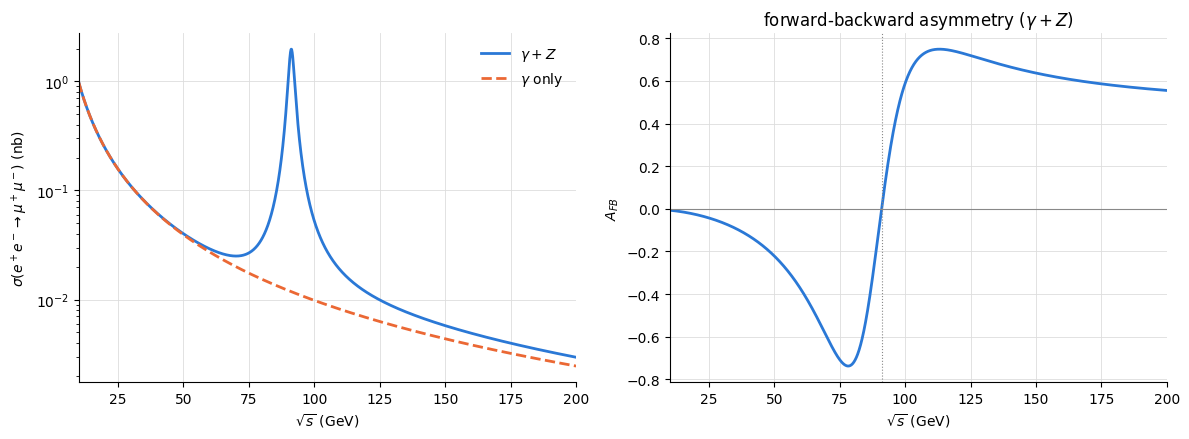

sqrt(s) =   35.0 GeV   A_FB =  -0.0906
sqrt(s) =   58.0 GeV   A_FB =  -0.3378
sqrt(s) =   91.2 GeV   A_FB =   0.0162
sqrt(s) =  130.0 GeV   A_FB =   0.7006
sqrt(s) =  200.0 GeV   A_FB =   0.5553

3/4 A_e A_mu =   0.0162


In [20]:
sqrts = np.linspace(10, 200, 2000)
sigma, afb     = cross_sections(sqrts)
sigma_g, afb_g = cross_sections(sqrts, photon_only=True)

BLUE, ORANGE = '#2a78d6', '#eb6834'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#dddddd', 'grid.linewidth': 0.6})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].semilogy(sqrts, sigma,   color=BLUE,   lw=2, label=r'$\gamma + Z$')
ax[0].semilogy(sqrts, sigma_g, color=ORANGE, lw=2, ls='--', label=r'$\gamma$ only')
ax[0].set_xlabel(r'$\sqrt{s}$ (GeV)')
ax[0].set_ylabel(r'$\sigma(e^+e^- \rightarrow \mu^+\mu^-)$ (nb)')
ax[0].set_xlim(10, 200)
ax[0].legend(frameon=False)

ax[1].plot(sqrts, afb, color=BLUE, lw=2)
ax[1].axhline(0, color='#888888', lw=0.8)
ax[1].axvline(MZ_, color='#888888', lw=0.8, ls=':')
ax[1].set_xlabel(r'$\sqrt{s}$ (GeV)')
ax[1].set_ylabel(r'$A_{FB}$')
ax[1].set_xlim(10, 200)
ax[1].set_title(r'forward-backward asymmetry ($\gamma + Z$)')

plt.tight_layout()
plt.show()

for e_ in [35.0, 58.0, MZ_, 130.0, 200.0]:
    _, A = cross_sections(np.array([e_]))
    print('sqrt(s) = %6.1f GeV   A_FB = %8.4f' % (e_, A[0]))

Ae_ = 2*gV_*gA_/(gV_**2 + gA_**2)
print('\n3/4 A_e A_mu = %8.4f' % (0.75*Ae_**2))

### Angular distributions

At the pole the $Z$ term exceeds the photon term by a factor of more than 100 and the distribution is almost symmetric. Well above the pole the interference term drives a large forward peak.

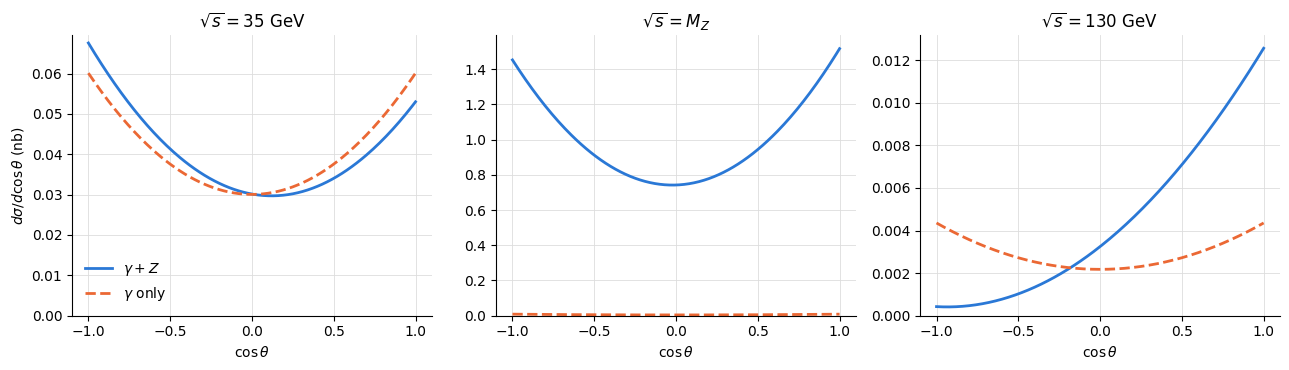

In [21]:
fdxs = sm.lambdify((x,) + args, dxs, 'numpy')

def dsigma_dcos(cost, sqrts_, photon_only=False):
    s_ = sqrts_**2
    b3 = np.sqrt(1 - 4*mmu_**2/s_)
    ch = 0j if photon_only else chi_(s_)
    # d sigma / d cos(theta) = 2 pi d sigma / d Omega
    return 2*np.pi*fdxs(cost, s_, b3, ch.real, ch.imag, MZ_) * GEV2NB

cost = np.linspace(-1, 1, 201)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for k, (e_, title) in enumerate([(35.0, r'$\sqrt{s} = 35$ GeV'), 
                                 (MZ_,  r'$\sqrt{s} = M_Z$'), 
                                 (130., r'$\sqrt{s} = 130$ GeV')]):
    ax[k].plot(cost, dsigma_dcos(cost, e_), color=BLUE, lw=2, label=r'$\gamma + Z$')
    ax[k].plot(cost, dsigma_dcos(cost, e_, photon_only=True), color=ORANGE, lw=2, ls='--', label=r'$\gamma$ only')
    ax[k].set_title(title)
    ax[k].set_xlabel(r'$\cos\theta$')
    ax[k].set_ylim(bottom=0)
ax[0].set_ylabel(r'$d\sigma/d\cos\theta$ (nb)')
ax[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## Bonus: polarized electron beam, $A_{LR}$

Because we have the individual helicity amplitudes, polarized cross sections cost nothing: simply sum $|M_\lambda|^2$ over the amplitudes with a left-handed (or right-handed) electron. In the massless limit the left-right asymmetry, measured by SLD at SLAC,
\begin{align}
    A_{LR} & = \frac{\sigma_L - \sigma_R}{\sigma_L + \sigma_R},
\end{align}
equals $\mathcal{A}_e = 2 g_V^e g_A^e/(g_V^{e2} + g_A^{e2})$ at the $Z$ pole, independent of the final state.

In [22]:
def sum_sq(amps):
    return sm.expand(sum([sm.expand(y.subs({I: -I})*y) for y in amps]))

MML = sum_sq([m for (ce, cm), m in zip(L0, M0) if ce == 'L'])
MMR = sum_sq([m for (ce, cm), m in zip(L0, M0) if ce == 'R'])

# integrate over the angles
xs_ = lambda y: sm.integrate(sm.expand(y.subs({sm.cos(theta): x})), (x, -1, 1))
ALR = (xs_(MML) - xs_(MMR)) / (xs_(MML) + xs_(MMR))

ALR = sm.simplify(ALR)   # alpha, s and E cancel in the ratio
chiral = {gLe: gV_ + gA_, gRe: gV_ - gA_, gLm: gV_ + gA_, gRm: gV_ - gA_, Qe: Q_, Qm: Q_}
fALR = sm.lambdify((chi_r, chi_i), ALR.subs(chiral), 'numpy')

ch = chi_(MZ_**2)
print('A_LR at the Z pole = %8.4f' % fALR(ch.real, ch.imag))
print('A_e                = %8.4f' % Ae_)

A_LR at the Z pole =   0.1463
A_e                =   0.1472


The small difference between $A_{LR}$ and $\mathcal{A}_e$ at the pole is due to the photon exchange and $\gamma$–$Z$ interference contributions, which are included in the helicity calculation. The measured value from SLD is $A_{LR} = 0.1514 \pm 0.0022$.